In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

print('✅ all of them loaded')

✅ all of them loaded


In [23]:
df = pd.read_csv('recipes.csv')

print(f'Dataset dimensions: {df.shape}  →  {df.shape[0]} recipe، {df.shape[1]} column')
print(f'\n columns: {df.columns.tolist()}')
print(f'\n Empty values: {df.isnull().sum().sum()} (Nothing!)')
df.head(3)

Dataset dimensions: (620, 5)  →  620 recipe، 5 column

 columns: ['name', 'area', 'category', 'ingredients', 'steps']

 Empty values: 0 (Nothing!)


,name,area,category,ingredients,steps
0,Hyderabad Soy Biryani With Vegetables & Palak,Indian,Main Course,"2 cups Basmati rice - soaked for 30 minutes,8 ...",To begin making Hyderabad Soy Biryani Recipe W...
1,Sagu Masala Dosa,Indian,South Indian Breakfast,"3/4 cup White Urad Dal (Split),1 cup Red matta...",*To Prepare the Dosa batterTo begin making the...
2,Chicken Burrito,Indian,Lunch,"300 grams Chicken - cut into stripes,1 Onion -...","To begin making the Chicken Burrito Recipe, we..."


Distribution of cuisine:
area
Indian        200
American       77
British        59
Spanish        48
Turkish        30
French         28
Chinese        27
Vietnamese     27
Polish         27
Jamaican       27
Thai           27
Canadian       22
Italian        21


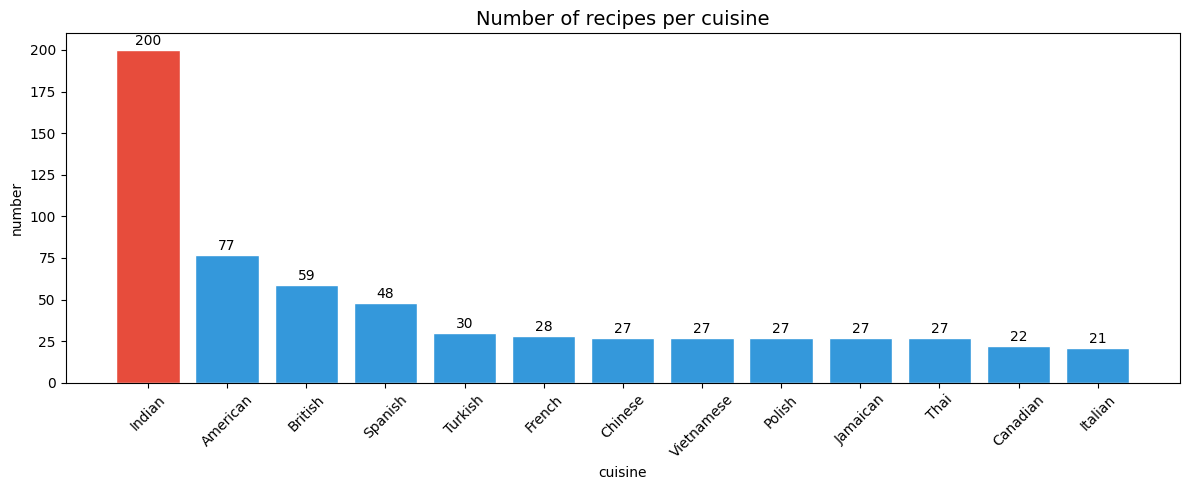


⚠️ point: Indian (200 record) relative to Italian (21 record) Much more!


In [24]:
counts = df['area'].value_counts()
print('Distribution of cuisine:')
print(counts.to_string())

plt.figure(figsize=(12, 5))
colors = ['#e74c3c' if c == counts.max() else '#3498db' for c in counts.values]
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='white')
plt.title('Number of recipes per cuisine', fontsize=14)
plt.xlabel('cuisine')
plt.ylabel('number')
plt.xticks(rotation=45)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print(f'\n⚠️ point: Indian ({counts.max()} record) relative to Italian ({counts.min()} record) Much more!')

In [25]:
import re
def clean_ingredients(text):
   
    text = text.lower()

    text = re.sub(r'\d+\/\d+|\d+', '', text)

    units = r'\b(cup|cups|tablespoon|tablespoons|tbsp|teaspoon|teaspoons|tsp|'\
            r'gram|grams|kg|pound|pounds|lb|lbs|oz|ounce|ounces|inch|inches|'\
            r'bunch|bunch|pinch|handful|piece|pieces|clove|cloves|slice|slices)\b'
    text = re.sub(units, '', text)

    text = re.sub(r'-[^,]*', ' ', text)

    text = re.sub(r'\([^)]*\)', ' ', text)

    text = re.sub(r'[^a-z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['clean_ingredients'] = df['ingredients'].apply(clean_ingredients)

print('Cleaning example:\n')
idx = 2
print(f'before:\n{df["ingredients"].iloc[idx][:200]}...')
print(f'\nafter:\n{df["clean_ingredients"].iloc[idx][:200]}')

Cleaning example:

before:
300 grams Chicken - cut into stripes,1 Onion - sliced,4 cloves Garlic - chopped,1 inch Ginger - chopped,1 tablespoon Cumin powder (Jeera),1 teaspoon Black pepper powder,1/2 teaspoon Cinnamon Powder (D...

after:
chicken onion garlic ginger cumin powder black pepper powder cinnamon powder paprika powder turmeric powder salt rajma onion tomato garlic cumin powder red chilli powder black pepper powder sugar salt


In [26]:
X = df['clean_ingredients']
y = df['area'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

print(f'Train: {len(X_train)} record ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test:  {len(X_test)} record ({len(X_test)/len(df)*100:.0f}%)')
print(f'number of class: {y.nunique()}  ←  {sorted(y.unique())}')

Train: 496 record (80%)
Test:  124 record (20%)
number of class: 13  ←  ['American', 'British', 'Canadian', 'Chinese', 'French', 'Indian', 'Italian', 'Jamaican', 'Polish', 'Spanish', 'Thai', 'Turkish', 'Vietnamese']


In [27]:
models = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=8000, sublinear_tf=True)),
        ('clf',   LogisticRegression(max_iter=1000, C=5, class_weight='balanced'))
    ]),
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=8000)),
        ('clf',   MultinomialNB(alpha=0.05))
    ]),
    'LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=8000, sublinear_tf=True)),
        ('clf',   LinearSVC(C=1.0, max_iter=2000, class_weight='balanced'))
    ])
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'acc': acc, 'pipeline': pipeline, 'y_pred': y_pred}
    print(f'{name:25s}  →  accuracy: {acc*100:.1f}%')

best_name = max(results, key=lambda x: results[x]['acc'])
print(f'\n🏆 best model: {best_name}  ({results[best_name]["acc"]*100:.1f}%)')

Logistic Regression        →  accuracy: 79.8%
Naive Bayes                →  accuracy: 77.4%
LinearSVC                  →  accuracy: 82.3%

🏆 best model: LinearSVC  (82.3%)


In [13]:
y_pred_best = results[best_name]['y_pred']
print(f'📊 Classification Report — {best_name}\n')
print(classification_report(y_test, y_pred_best))

📊 Classification Report — LinearSVC

              precision    recall  f1-score   support

    American       0.88      1.00      0.94        15
     British       0.82      0.75      0.78        12
    Canadian       0.67      0.50      0.57         4
     Chinese       0.80      0.80      0.80         5
      French       0.86      1.00      0.92         6
      Indian       0.98      1.00      0.99        40
     Italian       1.00      0.25      0.40         4
    Jamaican       0.83      0.83      0.83         6
      Polish       0.75      0.60      0.67         5
     Spanish       0.62      0.80      0.70        10
        Thai       0.67      0.40      0.50         5
     Turkish       0.60      0.50      0.55         6
  Vietnamese       0.50      0.67      0.57         6

    accuracy                           0.82       124
   macro avg       0.77      0.70      0.71       124
weighted avg       0.83      0.82      0.81       124



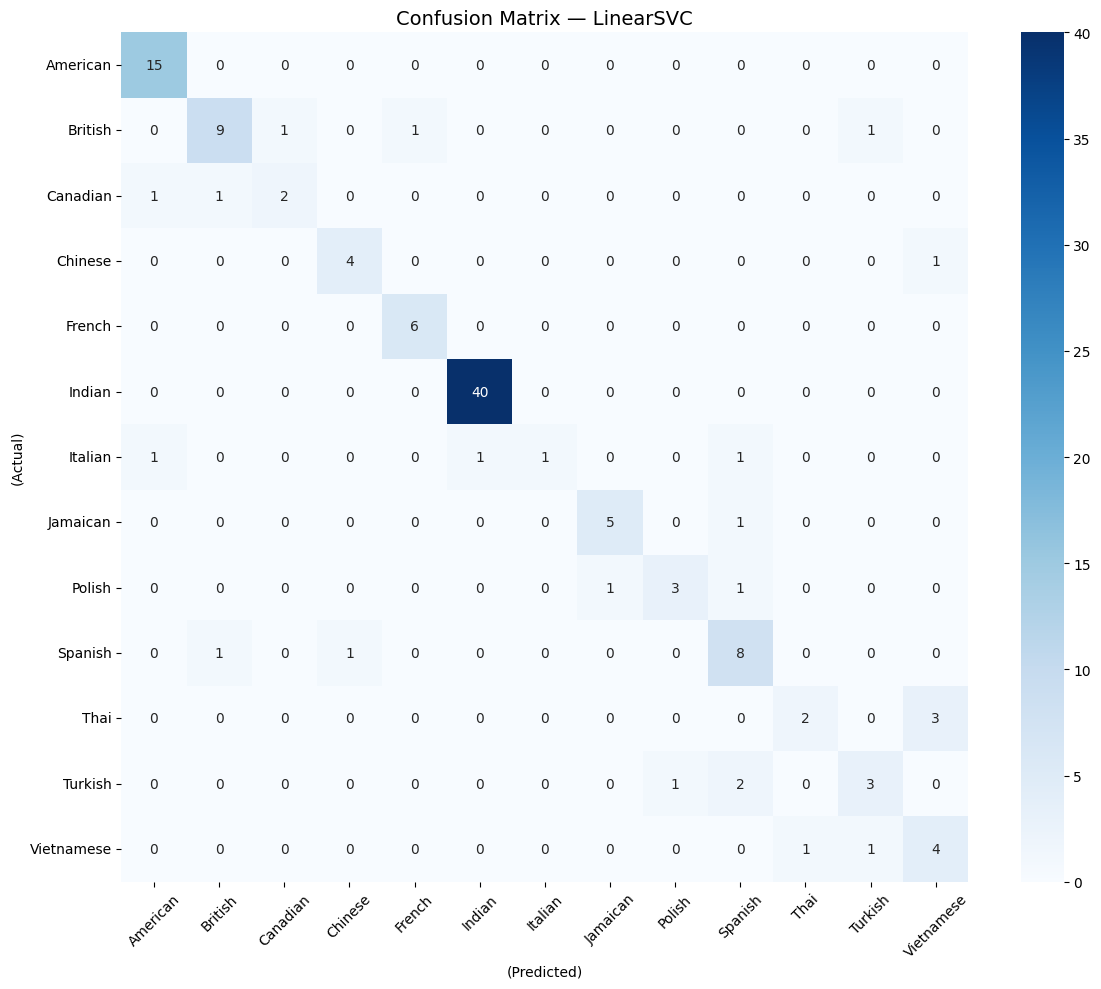

In [29]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix — {best_name}', fontsize=14)
plt.ylabel('(Actual)')
plt.xlabel('(Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

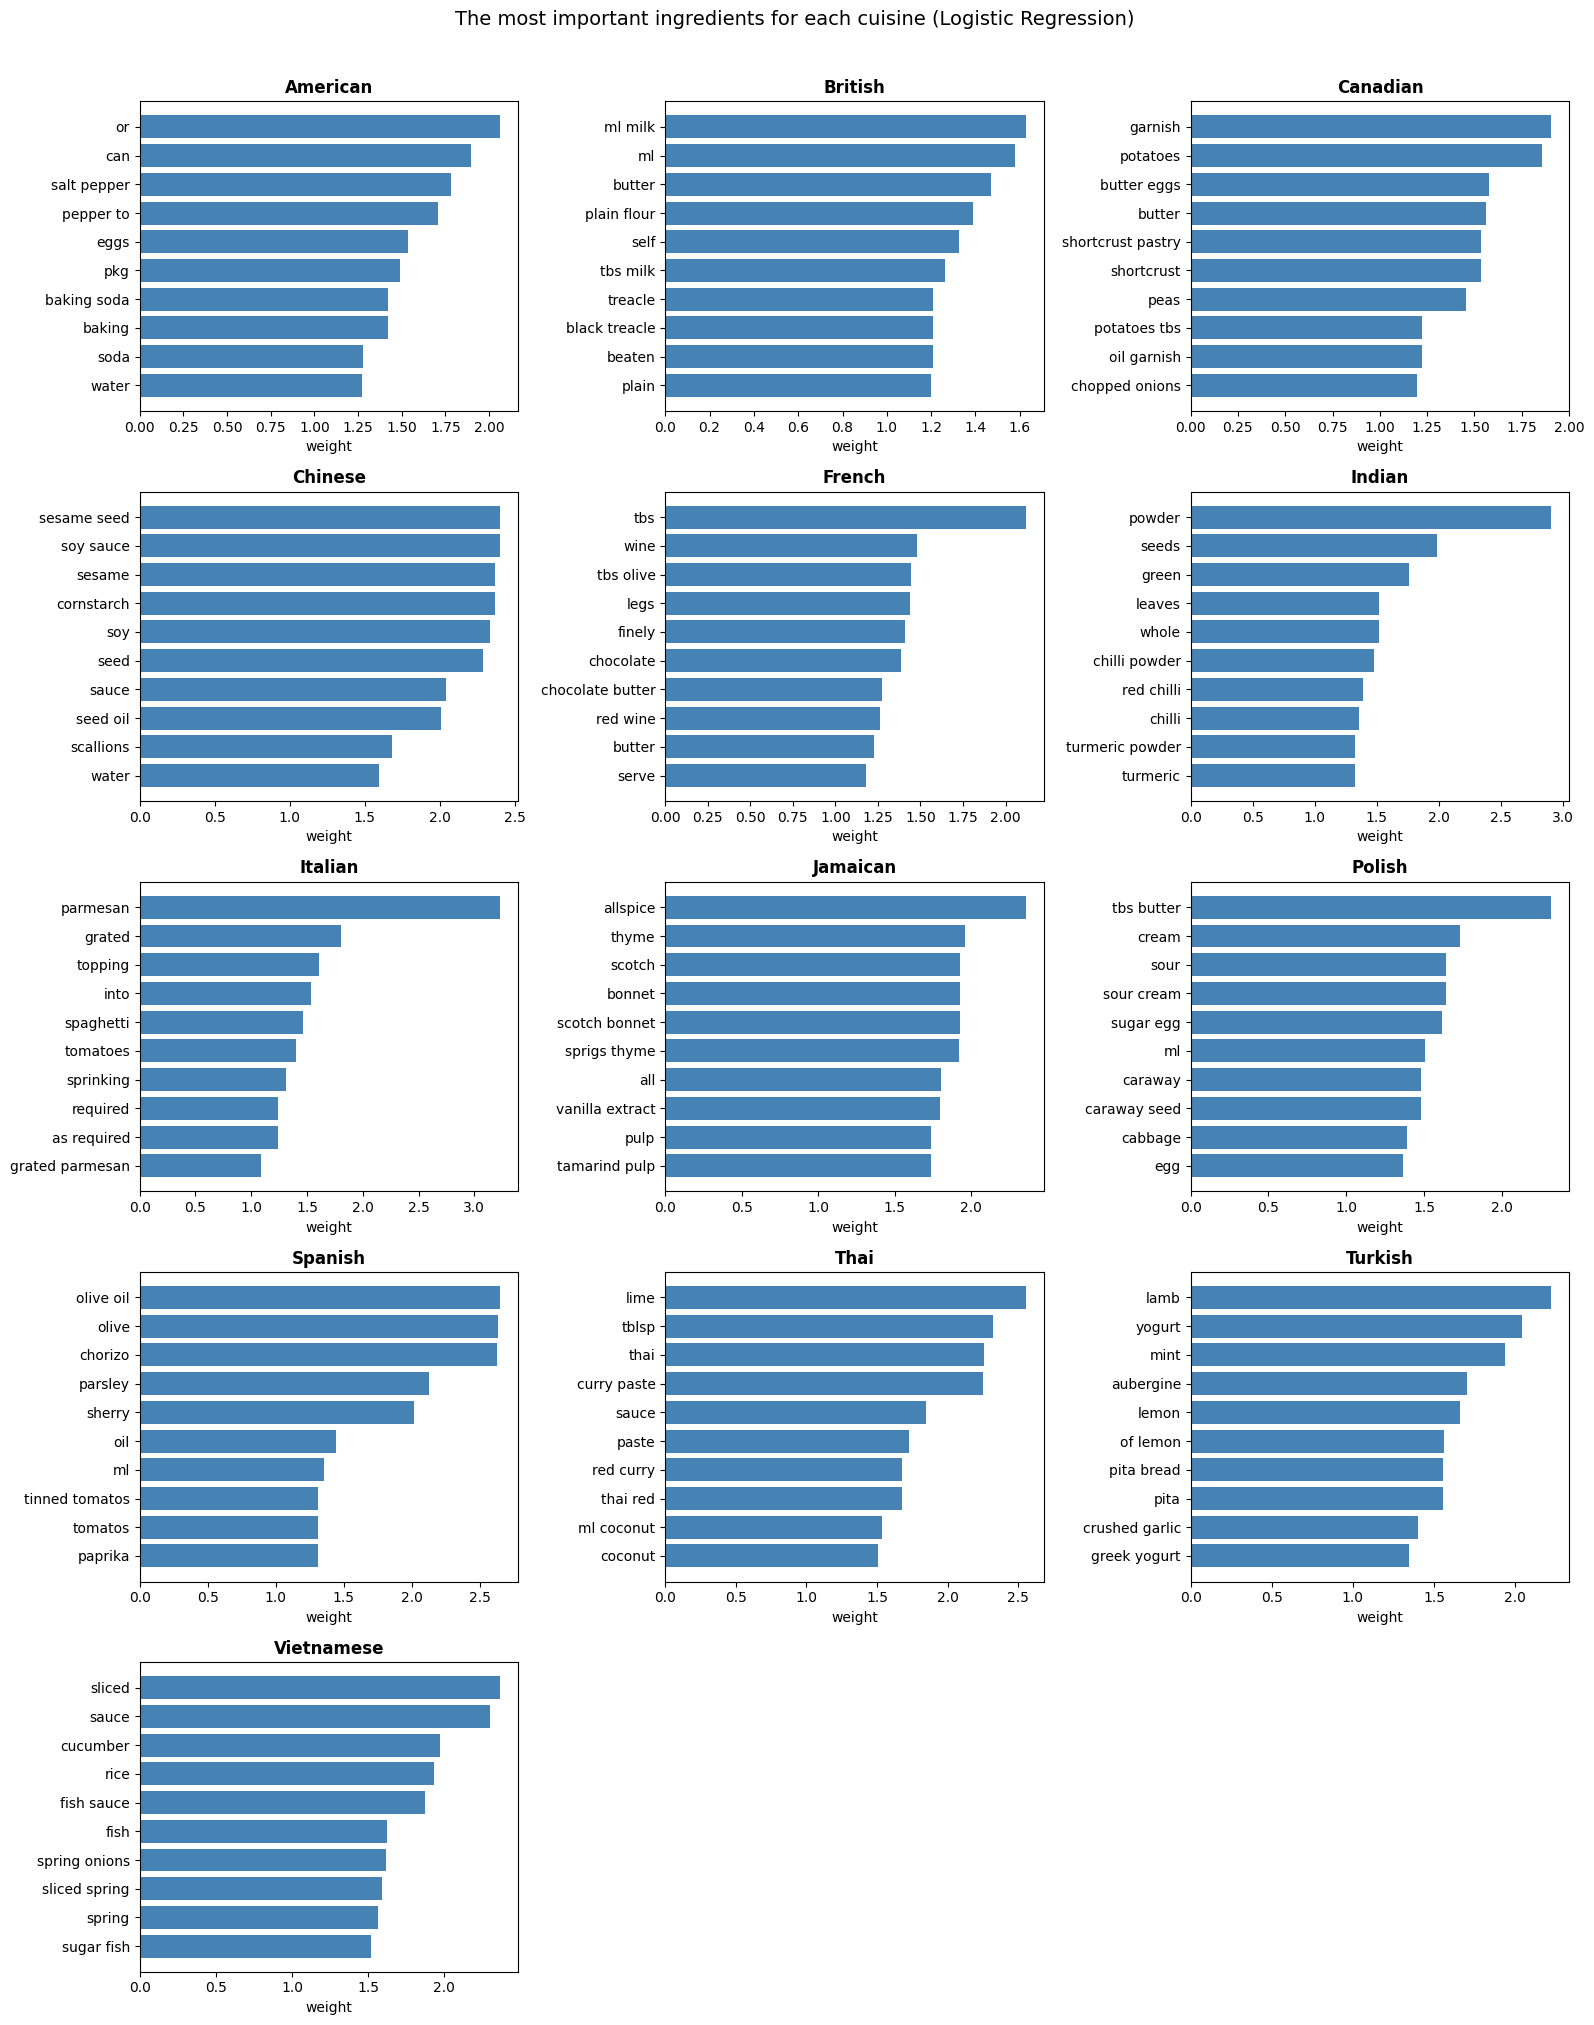

In [30]:
lr = results['Logistic Regression']['pipeline']
tfidf_vocab = lr.named_steps['tfidf'].get_feature_names_out()
clf_lr = lr.named_steps['clf']
class_names = clf_lr.classes_

n_cols = 3
n_rows = (len(class_names) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, (cls, coef) in enumerate(zip(class_names, clf_lr.coef_)):
    top_idx = coef.argsort()[-10:][::-1]
    features = [tfidf_vocab[j] for j in top_idx]
    scores   = [coef[j] for j in top_idx]
    axes[i].barh(features[::-1], scores[::-1], color='steelblue')
    axes[i].set_title(cls, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('weight')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('The most important ingredients for each cuisine (Logistic Regression)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [31]:
def predict_cuisine(ingredients_list, top_n=3):
   
    text = clean_ingredients(', '.join(ingredients_list))

    best_pipeline = results[best_name]['pipeline']
    pred = best_pipeline.predict([text])[0]

    print(f'🥘 Raw materials : {", ".join(ingredients_list)}')
    print(f'🌍 cuisine  : {pred}')

    lr_pipe = results['Logistic Regression']['pipeline']
    probs = lr_pipe.predict_proba([text])[0]
    classes = lr_pipe.classes_
    top_indices = probs.argsort()[-top_n:][::-1]
    print(f'\n📊 possibility top-{top_n} (Logistic Regression):')
    for idx in top_indices:
        print(f'   {classes[idx]:15s}: {probs[idx]*100:.1f}%')
    print()


predict_cuisine(['chicken', 'turmeric', 'garam masala', 'cumin', 'yogurt', 'onion', 'garlic'])
predict_cuisine(['soy sauce', 'ginger', 'sesame oil', 'rice', 'tofu', 'spring onion'])
predict_cuisine(['olive oil', 'garlic', 'tomato', 'basil', 'mozzarella', 'pasta'])
predict_cuisine(['jerk seasoning', 'scotch bonnet', 'allspice', 'thyme', 'chicken'])

🥘 Raw materials : chicken, turmeric, garam masala, cumin, yogurt, onion, garlic
🌍 cuisine  : Indian

📊 possibility top-3 (Logistic Regression):
   Indian         : 31.5%
   Turkish        : 22.3%
   American       : 7.2%

🥘 Raw materials : soy sauce, ginger, sesame oil, rice, tofu, spring onion
🌍 cuisine  : Chinese

📊 possibility top-3 (Logistic Regression):
   Chinese        : 50.1%
   Vietnamese     : 16.8%
   Indian         : 6.9%

🥘 Raw materials : olive oil, garlic, tomato, basil, mozzarella, pasta
🌍 cuisine  : Italian

📊 possibility top-3 (Logistic Regression):
   Italian        : 28.4%
   Spanish        : 24.7%
   American       : 8.3%

🥘 Raw materials : jerk seasoning, scotch bonnet, allspice, thyme, chicken
🌍 cuisine  : Jamaican

📊 possibility top-3 (Logistic Regression):
   Jamaican       : 74.4%
   French         : 2.8%
   Indian         : 2.6%



In [32]:
from sklearn.model_selection import train_test_split, cross_val_score

for name, model_data in results.items():
    cv_scores = cross_val_score(
        model_data['pipeline'], X, y,
        cv=5, scoring='accuracy'
    )
    print(f'{name:25s}  →  mean: {cv_scores.mean()*100:.1f}%  (±{cv_scores.std()*100:.1f}%)')

Logistic Regression        →  mean: 76.8%  (±2.2%)
Naive Bayes                →  mean: 76.6%  (±1.8%)
LinearSVC                  →  mean: 78.4%  (±2.2%)


In [33]:
import joblib
best_pipeline = results[best_name]['pipeline']
joblib.dump(best_pipeline, 'cuisine_classifier.pkl')

print(f'   model   : {best_name}')
print(f'   accuracy   : {results[best_name]["acc"]*100:.1f}%')

loaded = joblib.load('cuisine_classifier.pkl')
test_text = clean_ingredients('chicken turmeric garam masala')
print(f'\n🧪 Reload test: {loaded.predict([test_text])[0]}')

   model   : LinearSVC
   accuracy   : 82.3%

🧪 Reload test: Indian
